# Understand Dataset

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# import re
# import string

# from collections import Counter

In [ ]:
df=pd.read_csv("/content/Combined Data.csv")
df.head()

,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


In [ ]:
df.shape

(53044, 3)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53044 entries, 0 to 53043
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  53044 non-null  object
 1   statement   52681 non-null  object
 2   status      53042 non-null  object
dtypes: object(3)
memory usage: 1.2+ MB


In [ ]:
df.drop(columns='Unnamed: 0',inplace=True)

In [ ]:
df.isnull().sum()

,0
statement,363
status,2


In [ ]:
df.dropna(inplace=True)

In [ ]:
df.isnull().sum()

,0
statement,0
status,0


In [ ]:
df.duplicated().sum()

np.int64(1592)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.reset_index(drop=True, inplace=True)
df.shape

(51088, 2)

# EDA

In [ ]:
df['status'].value_counts()

,count
status,
Normal,16039
Depression,15093
Suicidal,10641
Anxiety,3623
Bipolar,2501
Stress,2296
Personality disorder,895


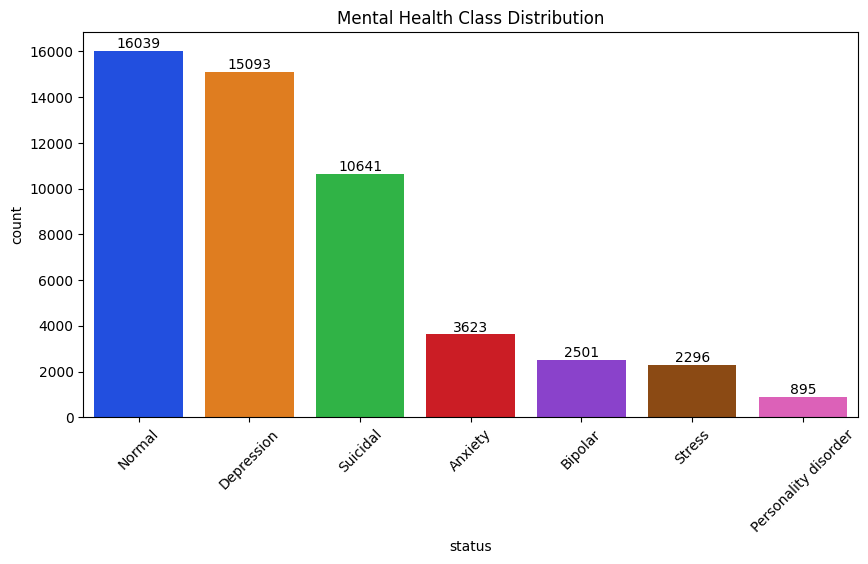

In [ ]:
plt.figure(figsize=(10,5))

ax=sns.countplot(
    data=df,
    x='status',
    order=df['status'].value_counts().index,
    palette="bright"
)
for i in ax.containers:
  ax.bar_label(i)

plt.title("Mental Health Class Distribution")
plt.xticks(rotation=45)
plt.show()

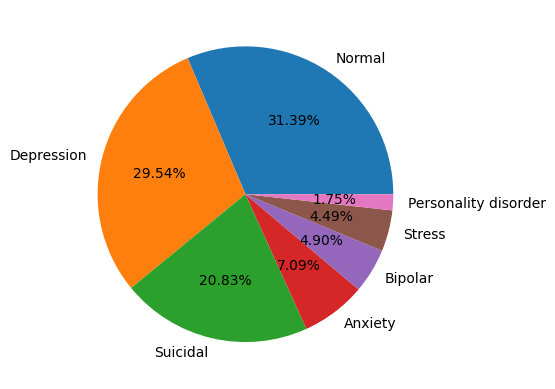

In [ ]:
counts = df['status'].value_counts()
labels = counts.index

plt.pie(counts, labels=labels, autopct='%1.2f%%')
plt.show()

In [ ]:
df['sentence_length'] = df['statement'].apply(len)
df.head()

,statement,status,sentence_length
0,oh my gosh,Anxiety,10
1,"trouble sleeping, confused mind, restless hear...",Anxiety,64
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,78
3,I've shifted my focus to something else but I'...,Anxiety,61
4,"I'm restless and restless, it's been a month n...",Anxiety,72


In [ ]:
# df['sentence_length'].describe()

In [ ]:
# plt.figure(figsize=(10,5))

# sns.histplot(df['char_length'], bins=50)

# plt.title("Character Length Distribution")

# plt.show()

In [ ]:
# plt.figure(figsize=(25, 6))  # Slightly wider figure so the numbers don't overlap

# # Define the sequence from 5 up to 100 (inclusive of 100) with a step of 5
# custom_bins = list(range(5, 1000, 5))

# # Pass the sequence to the bins parameter
# sns.histplot(df["word_count"], bins=custom_bins, kde=True)

# # Zoom in on the 0 to 105 range so the last bin fits nicely
# plt.xlim(0, 105)

# # Set the x-axis tick marks exactly at your bin intervals
# plt.xticks(list(range(5, 350, 5)))

# plt.title("Distribution of Statement Length")
# plt.xlabel("Number of Words")
# plt.show()

In [ ]:
df['word_count'] = df['statement'].apply(lambda x: len(str(x).split()))
df.head()

,statement,status,sentence_length,word_count
0,oh my gosh,Anxiety,10,3
1,"trouble sleeping, confused mind, restless hear...",Anxiety,64,10
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,78,14
3,I've shifted my focus to something else but I'...,Anxiety,61,11
4,"I'm restless and restless, it's been a month n...",Anxiety,72,14


In [ ]:
# df['word_count'].describe()

In [ ]:
# plt.figure(figsize=(10,5))

# sns.histplot(df['word_count'], bins=50)

# plt.title("Word Count Distribution")

# plt.show()

In [ ]:
# df['avg_word_length'] = (df['sentence_length'] / df['word_count'])
# df.head()

In [ ]:
df['vocabulary_size'] = df['statement'].apply(lambda x: len(set(str(x).split())))
df.head()

,statement,status,sentence_length,word_count,vocabulary_size
0,oh my gosh,Anxiety,10,3,3
1,"trouble sleeping, confused mind, restless hear...",Anxiety,64,10,10
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,78,14,13
3,I've shifted my focus to something else but I'...,Anxiety,61,11,11
4,"I'm restless and restless, it's been a month n...",Anxiety,72,14,14


In [ ]:
from collections import Counter

all_words = " ".join(df['statement']).split()

word_freq = Counter(all_words)

word_freq.most_common(20)

[('I', 309231),
 ('to', 187663),
 ('and', 162747),
 ('the', 115333),
 ('a', 111401),
 ('my', 105434),
 ('of', 80997),
 ('i', 77820),
 ('not', 71591),
 ('is', 66935),
 ('have', 66845),
 ('it', 63620),
 ('that', 61135),
 ('am', 59957),
 ('in', 56760),
 ('me', 54410),
 ('do', 50218),
 ('for', 50178),
 ('but', 47067),
 ('just', 45084)]

In [ ]:
# from wordcloud import WordCloud

# text = " ".join(df['statement'])

# wordcloud = WordCloud(
#     width=1200,
#     height=600,
#     background_color='white'
# ).generate(text)

# plt.figure(figsize=(15,8))

# plt.imshow(wordcloud)

# plt.axis("off")

# plt.show()

# Preprocessing

In [ ]:
df['statement'].sample(5,random_state=10).values

array(['Yup like I said no idea, guess I got no one else but strangers online and texts on a screen. I cannot seem to figure out a reason to keep going. Life just seems like pain, sadness and hardship until you die. I have everything I was taught I should be grateful for, a loving and supportive girlfriend, good money, great friends, and a good family but I cannot stop the almost daily thoughts of throwing it all away forever. it is so fucking frustrating and makes no sense why I feel this way. A good friend of mine recently committed suicide and it really messed me up. I used to think about all the people in my life that would miss me if I gave into my thoughts like I was doing them a favor by not going through with it like I am special or something. But I am not I am just 1 of 7 billion and life will go on with or without me. I do not know what I am expecting from doing this but I have heard talking about shit helps Not really sure why I am doing this',
       "How can you reduce the

In [ ]:
# Install required libraries
!pip install emoji

# Standard Libraries
import re
import html
import unicodedata

# Third-party Libraries
import emoji


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 11.9 MB/s eta 0:00:00


In [ ]:
def normalize_unicode(text):
    """Normalize Unicode characters."""
    return unicodedata.normalize("NFKC", text)


def remove_urls(text):
    """Remove URLs."""
    return re.sub(r"http\S+|www\S+", "", text)


def remove_html(text):
    """Remove HTML tags and decode HTML entities."""
    text = html.unescape(text)
    return re.sub(r"<.*?>", "", text)


def remove_emails(text):
    """Remove email addresses."""
    return re.sub(r"\S+@\S+", "", text)


def remove_mentions(text):
    """Remove social media mentions."""
    return re.sub(r"@\w+", "", text)


def convert_emojis(text):
    """Convert emojis into text descriptions."""
    return emoji.demojize(text, delimiters=(" ", " "))


def remove_extra_spaces(text):
    """Normalize multiple spaces."""
    return re.sub(r"\s+", " ", text).strip()

In [ ]:
def preprocess_text(text):
    """
    Minimal preprocessing for DistilBERT.
    Preserve natural language as much as possible.
    """

    text = str(text)

    text = normalize_unicode(text)
    text = remove_html(text)
    text = remove_urls(text)
    text = remove_emails(text)
    text = remove_mentions(text)
    text = convert_emojis(text)
    text = remove_extra_spaces(text)

    return text

In [ ]:
df["bert_text"] = df["statement"].apply(preprocess_text)

In [ ]:
comparison = pd.DataFrame({
    "Original": df["statement"],
    "BERT Text": df["bert_text"]
})

comparison.head(10)

,Original,BERT Text
0,oh my gosh,oh my gosh
1,"trouble sleeping, confused mind, restless hear...","trouble sleeping, confused mind, restless hear..."
2,"All wrong, back off dear, forward doubt. Stay ...","All wrong, back off dear, forward doubt. Stay ..."
3,I've shifted my focus to something else but I'...,I've shifted my focus to something else but I'...
4,"I'm restless and restless, it's been a month n...","I'm restless and restless, it's been a month n..."
5,"every break, you must be nervous, like somethi...","every break, you must be nervous, like somethi..."
6,"I feel scared, anxious, what can I do? And may...","I feel scared, anxious, what can I do? And may..."
7,Have you ever felt nervous but didn't know why?,Have you ever felt nervous but didn't know why?
8,"I haven't slept well for 2 days, it's like I'm...","I haven't slept well for 2 days, it's like I'm..."
9,"I'm really worried, I want to cry.","I'm really worried, I want to cry."


In [ ]:
df['bert_text'].sample(5,random_state=10).values

array(['Yup like I said no idea, guess I got no one else but strangers online and texts on a screen. I cannot seem to figure out a reason to keep going. Life just seems like pain, sadness and hardship until you die. I have everything I was taught I should be grateful for, a loving and supportive girlfriend, good money, great friends, and a good family but I cannot stop the almost daily thoughts of throwing it all away forever. it is so fucking frustrating and makes no sense why I feel this way. A good friend of mine recently committed suicide and it really messed me up. I used to think about all the people in my life that would miss me if I gave into my thoughts like I was doing them a favor by not going through with it like I am special or something. But I am not I am just 1 of 7 billion and life will go on with or without me. I do not know what I am expecting from doing this but I have heard talking about shit helps Not really sure why I am doing this',
       "How can you reduce the

# Label Encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df["label"] = label_encoder.fit_transform(df["status"])

num_classes = len(label_encoder.classes_)

print(label_encoder.classes_)
print(f"Number of classes: {num_classes}")

# print(y[49200:49300])

['Anxiety' 'Bipolar' 'Depression' 'Normal' 'Personality disorder' 'Stress'
 'Suicidal']
Number of classes: 7


In [ ]:
label_mapping = dict(zip(label_encoder.classes_,
                         label_encoder.transform(label_encoder.classes_)))

print(label_mapping)

{'Anxiety': np.int64(0), 'Bipolar': np.int64(1), 'Depression': np.int64(2), 'Normal': np.int64(3), 'Personality disorder': np.int64(4), 'Stress': np.int64(5), 'Suicidal': np.int64(6)}


# Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X = df["bert_text"]
y = df["label"]

# 80% Train, 20% Temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Split the remaining 20% into Validation (10%) and Test (10%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [ ]:
print(f"Training Samples   : {len(X_train)}")
print(f"Validation Samples : {len(X_val)}")
print(f"Testing Samples    : {len(X_test)}")

Training Samples   : 40870
Validation Samples : 5109
Testing Samples    : 5109


In [ ]:
print("Train Distribution")
print(y_train.value_counts(normalize=True).sort_index())

print("\nValidation Distribution")
print(y_val.value_counts(normalize=True).sort_index())

print("\nTest Distribution")
print(y_test.value_counts(normalize=True).sort_index())

Train Distribution
label
0    0.070908
1    0.048960
2    0.295425
3    0.313947
4    0.017519
5    0.044947
6    0.208295
Name: proportion, dtype: float64

Validation Distribution
label
0    0.071051
1    0.048933
2    0.295557
3    0.313956
4    0.017420
5    0.044823
6    0.208260
Name: proportion, dtype: float64

Test Distribution
label
0    0.070855
1    0.048933
2    0.295361
3    0.313956
4    0.017616
5    0.045019
6    0.208260
Name: proportion, dtype: float64


# Load DistilBERT Tokenizer

In [ ]:
# Sentence
#       ↓
# DistilBERT Tokenizer
#       ↓
# Input IDs
#       ↓
# Pretrained DistilBERT Embeddings

In [ ]:
!pip install -q transformers datasets accelerate tqdm

In [ ]:
from transformers import AutoTokenizer

In [ ]:
MODEL_NAME = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
print("Vocabulary Size :", tokenizer.vocab_size)
print("Model Max Length:", tokenizer.model_max_length)
print("Padding Token   :", tokenizer.pad_token)
print("CLS Token       :", tokenizer.cls_token)
print("SEP Token       :", tokenizer.sep_token)
print("UNK Token       :", tokenizer.unk_token)

Vocabulary Size : 30522
Model Max Length: 512
Padding Token   : [PAD]
CLS Token       : [CLS]
SEP Token       : [SEP]
UNK Token       : [UNK]


In [ ]:
sample_text = X_train.iloc[0]

print(sample_text)

a pc or a mac?


In [ ]:
encoded = tokenizer(sample_text)

encoded

{'input_ids': [101, 1037, 7473, 2030, 1037, 6097, 1029, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1]}

In [ ]:
print("Input IDs:")
print(encoded["input_ids"])

print("\nAttention Mask:")
print(encoded["attention_mask"])

Input IDs:
[101, 1037, 7473, 2030, 1037, 6097, 1029, 102]

Attention Mask:
[1, 1, 1, 1, 1, 1, 1, 1]


In [ ]:
tokens = tokenizer.convert_ids_to_tokens(encoded["input_ids"])

print(tokens)

['[CLS]', 'a', 'pc', 'or', 'a', 'mac', '?', '[SEP]']


In [ ]:
for token, token_id in zip(tokens, encoded["input_ids"]):
    print(f"{token:<15} -> {token_id}")

[CLS]           -> 101
a               -> 1037
pc              -> 7473
or              -> 2030
a               -> 1037
mac             -> 6097
?               -> 1029
[SEP]           -> 102


In [ ]:
sample = "I am feeling unbelievably depressed today."

encoded = tokenizer(sample)

tokens = tokenizer.convert_ids_to_tokens(encoded["input_ids"])

print(tokens)

['[CLS]', 'i', 'am', 'feeling', 'un', '##bel', '##ie', '##va', '##bly', 'depressed', 'today', '.', '[SEP]']


# Finding the Optimal max_length

In [ ]:
token_lengths = X_train.apply(
    lambda x: len(tokenizer.encode(x, add_special_tokens=True))
)

In [ ]:
print(token_lengths.describe())

count    40870.000000
mean       134.997871
std        188.922508
min          2.000000
25%         22.000000
50%         75.000000
75%        175.000000
max       5857.000000
Name: bert_text, dtype: float64


In [ ]:
print("90th percentile :", token_lengths.quantile(0.90))
print("95th percentile :", token_lengths.quantile(0.95))
print("99th percentile :", token_lengths.quantile(0.99))
print("Maximum :", token_lengths.max())

90th percentile : 328.0
95th percentile : 462.0
99th percentile : 862.3099999999977
Maximum : 5857


In [ ]:
# import matplotlib.pyplot as plt

# plt.figure(figsize=(10, 5))
# plt.hist(token_lengths, bins=50)
# plt.xlabel("Token Length")
# plt.ylabel("Number of Samples")
# plt.title("Distribution of Token Lengths")
# plt.show()

# Tokenize the Entire Dataset

In [ ]:
MAX_LENGTH = 384 #512

train_encodings = tokenizer(
    X_train.tolist(),
    truncation=True,
    padding=True,
    max_length=MAX_LENGTH
)

val_encodings = tokenizer(
    X_val.tolist(),
    truncation=True,
    padding=True,
    max_length=MAX_LENGTH
)

test_encodings = tokenizer(
    X_test.tolist(),
    truncation=True,
    padding=True,
    max_length=MAX_LENGTH
)

# Creating a Custom PyTorch Dataset

In [ ]:
import torch
from torch.utils.data import Dataset

In [ ]:
class MentalHealthDataset(Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.tolist()

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):

        item = {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }

        item["labels"] = torch.tensor(self.labels[idx])

        return item

In [ ]:
train_dataset = MentalHealthDataset(
    train_encodings,
    y_train
)

val_dataset = MentalHealthDataset(
    val_encodings,
    y_val
)

test_dataset = MentalHealthDataset(
    test_encodings,
    y_test
)

In [ ]:
sample = train_dataset[0]

print(sample.keys())

dict_keys(['input_ids', 'token_type_ids', 'attention_mask', 'labels'])


In [ ]:
print(sample["input_ids"].shape)
print(sample["attention_mask"].shape)
print(sample["labels"])

torch.Size([384])
torch.Size([384])
tensor(3)


In [ ]:
print(sample["input_ids"].dtype)
print(sample["attention_mask"].dtype)
print(sample["labels"].dtype)

torch.int64
torch.int64
torch.int64


# DataLoader

In [ ]:
from torch.utils.data import DataLoader

In [ ]:
BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [ ]:
batch = next(iter(train_loader))

In [ ]:
print(batch["input_ids"].shape)
print(batch["attention_mask"].shape)
print(batch["labels"].shape)

torch.Size([16, 384])
torch.Size([16, 384])
torch.Size([16])


# Loading the Pretrained Model

In [ ]:
# Embedding Layer
#         ↓
# BiLSTM
#         ↓
# Attention
#         ↓
# Dense
#         ↓
# Softmax

In [ ]:
# DistilBERT Encoder
#         ↓
# Transformer Layer 1
#         ↓
# Transformer Layer 2
#         ↓
# Transformer Layer 3
#         ↓
# Transformer Layer 4
#         ↓
# Transformer Layer 5
#         ↓
# Transformer Layer 6

In [ ]:
# Input IDs
#       ↓
# Embedding Layer
#       ↓
# Transformer Block × 6
#       ↓
# CLS Representation
#       ↓
# Dropout
#       ↓
# Linear Classifier
#       ↓
# 7 Class Probabilities

In [ ]:
from transformers import DistilBertForSequenceClassification

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=num_classes
)
model.to(device)

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [ ]:
print(model)

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [ ]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")

Total Parameters: 66,958,855
Trainable Parameters: 66,958,855


# The Forward Pass

In [ ]:
batch = next(iter(train_loader))

In [ ]:
input_ids = batch["input_ids"].to(device)
attention_mask = batch["attention_mask"].to(device)
labels = batch["labels"].to(device)

outputs = model(
    input_ids=input_ids,
    attention_mask=attention_mask,
    labels=labels
)

In [ ]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

True
Tesla T4


In [ ]:
print(type(outputs))
print(outputs.keys())

<class 'transformers.modeling_outputs.SequenceClassifierOutput'>
odict_keys(['loss', 'logits'])


In [ ]:
print("Loss:", outputs.loss)

print("Logits Shape:", outputs.logits.shape)

print(outputs.logits)

Loss: tensor(2.0241, device='cuda:0', grad_fn=<NllLossBackward0>)
Logits Shape: torch.Size([16, 7])
tensor([[-2.3890e-02, -4.6070e-02, -1.7521e-01, -1.6743e-01,  1.0183e-01,
         -3.2111e-02,  3.9184e-02],
        [-2.6017e-02, -1.2672e-02, -2.5477e-01, -1.6574e-01, -1.3733e-02,
         -5.6188e-02,  5.0519e-02],
        [-5.2907e-02,  3.2518e-02, -1.6230e-01, -1.9899e-01,  4.7528e-02,
         -1.2963e-01,  4.4231e-02],
        [-5.4954e-02, -9.3721e-03, -2.2301e-01, -7.9605e-02, -9.9128e-03,
         -8.5638e-03,  7.0809e-02],
        [-1.5414e-02,  1.6116e-02, -2.0725e-01, -2.1033e-01,  1.0533e-02,
         -7.2797e-02,  3.2486e-02],
        [-2.8402e-03, -5.4560e-03, -2.2310e-01, -1.8217e-01,  7.6774e-02,
         -6.5956e-02,  4.6301e-03],
        [-5.1474e-02, -2.7605e-02, -1.7703e-01, -1.8245e-01, -2.4021e-02,
         -1.0125e-01,  3.2421e-02],
        [-3.4622e-02, -1.6312e-02, -2.3789e-01, -1.9497e-01,  2.9942e-02,
         -7.5177e-02,  2.3704e-02],
        [-1.3522e-03

In [ ]:
import torch

probabilities = torch.softmax(outputs.logits, dim=1)

print(probabilities.shape)
print(probabilities[0])
print(probabilities[0].sum())

torch.Size([16, 7])
tensor([0.1450, 0.1419, 0.1247, 0.1256, 0.1645, 0.1438, 0.1545],
       device='cuda:0', grad_fn=<SelectBackward0>)
tensor(1., device='cuda:0', grad_fn=<SumBackward0>)


In [ ]:
predictions = torch.argmax(outputs.logits, dim=1)

print(predictions)

tensor([4, 6, 4, 6, 6, 4, 6, 4, 4, 6, 4, 6, 6, 6, 6, 4], device='cuda:0')


# Optimizer & Learning Rate Scheduler

In [ ]:
# Forward Pass
#       ↓
# Compute Loss
#       ↓
# Backpropagation
#       ↓
# Optimizer updates weights

In [ ]:
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

optimizer = AdamW(
    model.parameters(),
    lr=2e-5,
    weight_decay=0.01
)

EPOCHS = 3 #5 #3
total_training_steps = len(train_loader) * EPOCHS

print("Training Steps:", total_training_steps)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=total_training_steps
)

Training Steps: 7665


# Training Loop

In [ ]:
# For every epoch
#     For every batch
#         1. Move data to device
#         2. Forward Pass
#         3. Compute Loss
#         4. Backpropagation
#         5. Optimizer Step
#         6. Scheduler Step
#         7. Record Metrics

In [ ]:
# ============================
# Training History
# ============================

train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []

val_precisions = []
val_recalls = []
val_f1_scores = []

In [ ]:
def train_one_epoch(
        model,
        dataloader,
        optimizer,
        scheduler,
        device
):
    model.train()

    running_loss = 0
    correct = 0
    total = 0

    progress_bar = tqdm(
        dataloader,
        desc="Training"
    )

    for batch in progress_bar:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss

        predictions = torch.argmax(
            outputs.logits,
            dim=1
        )

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

        loss.backward()

        optimizer.step()
        scheduler.step()

        running_loss += loss.item()

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}",
            acc=f"{100 * correct / total:.2f}%"
        )

    epoch_loss = running_loss / len(dataloader)
    epoch_accuracy = 100 * correct / total

    # Removed history appends from here, handled in main loop

    return epoch_loss, epoch_accuracy

# Validation loop

In [ ]:
def validate_one_epoch(
        model,
        dataloader,
        device
):
    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss

            predictions = torch.argmax(
                outputs.logits,
                dim=1
            )

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

            running_loss += loss.item()

            all_predictions.extend(
                predictions.cpu().numpy()
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

    # Step 10 — Compute Epoch Metrics
    epoch_loss = running_loss / len(dataloader)
    epoch_accuracy = 100 * correct / total

    # Step 11 — Compute Precision, Recall and F1
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0
    )

    # Removed: Step 12 — Save Validation History

    # Step 13 — Return the Results
    return (
        epoch_loss,
        epoch_accuracy,
        precision,
        recall,
        f1
    )

# Fit

In [ ]:
# ============================
# Best Model Tracking
# ============================

best_val_accuracy = 0

best_epoch = 0

patience = 3 # Increased patience as suggested
patience_counter = 0

In [ ]:
from tqdm import tqdm # Changed import statement
import time

start_time = time.time() # Added time tracking

for epoch in range(EPOCHS):

    print("=" * 70)

    print(f"Epoch {epoch+1}/{EPOCHS}")

    print("=" * 70)

    # Step 3 — Train
    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        optimizer,
        scheduler,
        device
    )

    # Step 4 — Validate
    (
        val_loss,
        val_accuracy,
        val_precision,
        val_recall,
        val_f1
    ) = validate_one_epoch(
        model,
        val_loader,
        device
    )

    # Append to history lists in the main loop
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)
    val_precisions.append(val_precision)
    val_recalls.append(val_recall)
    val_f1_scores.append(val_f1)

    # Step 5 — Print Metrics
    print(f"\nTraining Loss      : {train_loss:.4f}")
    print(f"Training Accuracy  : {train_accuracy:.2f}%")

    print(f"\nValidation Loss    : {val_loss:.4f}")
    print(f"Validation Accuracy: {val_accuracy:.2f}%")
    print(f"Validation Precision: {val_precision:.4f}")
    print(f"Validation Recall   : {val_recall:.4f}")
    print(f"Validation F1-Score : {val_f1:.4f}")

    # Step 6 — Save the Best Model
    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        best_epoch = epoch + 1

        patience_counter = 0

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "best_val_accuracy": best_val_accuracy,
            },
            "best_distilbert.pt"
        )

        print("✅ Best model saved!")

    else:

        patience_counter += 1

    # Step 7 — Early Stopping
    if patience_counter >= patience:

        print("\nEarly stopping triggered!")

        break

end_time = time.time() # Added time tracking

print(f"\nTotal Training Time : {(end_time - start_time)/60:.2f} minutes") # Print total training time

Epoch 1/3


Training:   0%|          | 0/2555 [00:00<?, ?it/s]


Training Loss      : 0.5011
Training Accuracy  : 80.04%

Validation Loss    : 0.4349
Validation Accuracy: 82.50%
Validation Precision: 0.8136
Validation Recall   : 0.7615
Validation F1-Score : 0.7767
✅ Best model saved!
Epoch 2/3


Training:   0%|          | 0/2555 [00:00<?, ?it/s]


Training Loss      : 0.3520
Training Accuracy  : 85.69%

Validation Loss    : 0.3863
Validation Accuracy: 84.36%
Validation Precision: 0.8152
Validation Recall   : 0.8114
Validation F1-Score : 0.8126
✅ Best model saved!
Epoch 3/3


Training:   0%|          | 0/2555 [00:00<?, ?it/s]


Training Loss      : 0.2675
Training Accuracy  : 89.46%

Validation Loss    : 0.4001
Validation Accuracy: 84.46%
Validation Precision: 0.8178
Validation Recall   : 0.8057
Validation F1-Score : 0.8108
✅ Best model saved!

Total Training Time : 77.55 minutes


In [ ]:
# Step 8 — Final Summary
print("=" * 70)

print(f"Best Validation Accuracy : {best_val_accuracy:.2f}%")

print(f"Best Epoch               : {best_epoch}") # Adjusted spacing
print(f"Model Saved As           : best_distilbert.pt") # Added model save name

print("=" * 70)

Best Validation Accuracy : 84.46%
Best Epoch               : 3
Model Saved As           : best_distilbert.pt


# Test Evaluation

In [ ]:
model.load_state_dict(torch.load("best_distilbert.pt")["model_state_dict"])

<All keys matched successfully>

In [ ]:
model.eval()

test_predictions = []
test_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        predictions = torch.argmax(
            outputs.logits,
            dim=1
        )

        test_predictions.extend(
            predictions.cpu().numpy()
        )

        test_labels.extend(
            labels.cpu().numpy()
        )

In [ ]:
test_accuracy = accuracy_score(test_labels, test_predictions)
test_precision, test_recall, test_f1, _ = precision_recall_fscore_support(test_labels, test_predictions, average='macro', zero_division=0)

print(f"Test Accuracy   : {test_accuracy:.4f}")
print(f"Test Precision  : {test_precision:.4f}")
print(f"Test Recall     : {test_recall:.4f}")
print(f"Test F1-Score   : {test_f1:.4f}")

Test Accuracy   : 0.8281
Test Precision  : 0.8045
Test Recall     : 0.7895
Test F1-Score   : 0.7951


**Classification Report**

In [ ]:
print(classification_report(test_labels, test_predictions, target_names=label_encoder.classes_))

                      precision    recall  f1-score   support

             Anxiety       0.86      0.87      0.87       362
             Bipolar       0.85      0.82      0.83       250
          Depression       0.81      0.73      0.77      1509
              Normal       0.95      0.97      0.95      1604
Personality disorder       0.75      0.60      0.67        90
              Stress       0.72      0.76      0.74       230
            Suicidal       0.70      0.78      0.74      1064

            accuracy                           0.83      5109
           macro avg       0.80      0.79      0.80      5109
        weighted avg       0.83      0.83      0.83      5109



**Confusion Matrix**

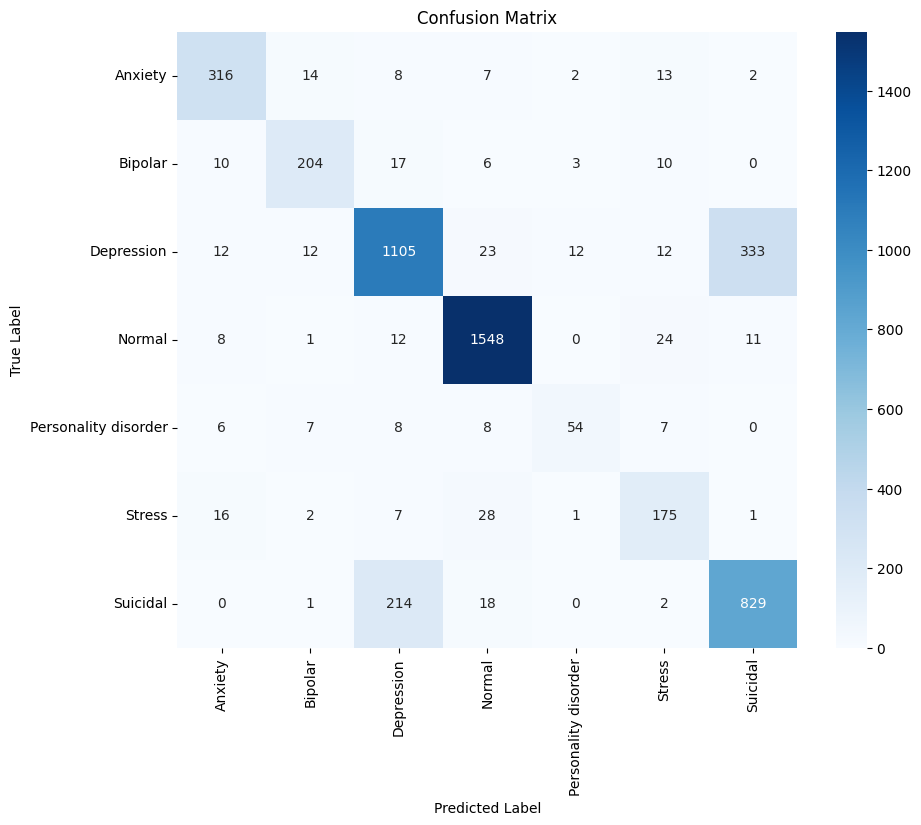

In [ ]:
cm = confusion_matrix(test_labels, test_predictions)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

**ROC-AUC**

In [ ]:
from sklearn.preprocessing import LabelBinarizer

# Binarize the labels for ROC AUC calculation
label_binarizer = LabelBinarizer()
y_test_binarized = label_binarizer.fit_transform(test_labels)

# Get predicted probabilities for ROC AUC
model.eval()
all_probs = []
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        probabilities = torch.softmax(outputs.logits, dim=1)
        all_probs.extend(probabilities.cpu().numpy())

roc_auc = roc_auc_score(y_test_binarized, all_probs, average='macro')
print(f"Macro-averaged ROC AUC: {roc_auc:.4f}")

Macro-averaged ROC AUC: 0.9768


**Learning Curves**

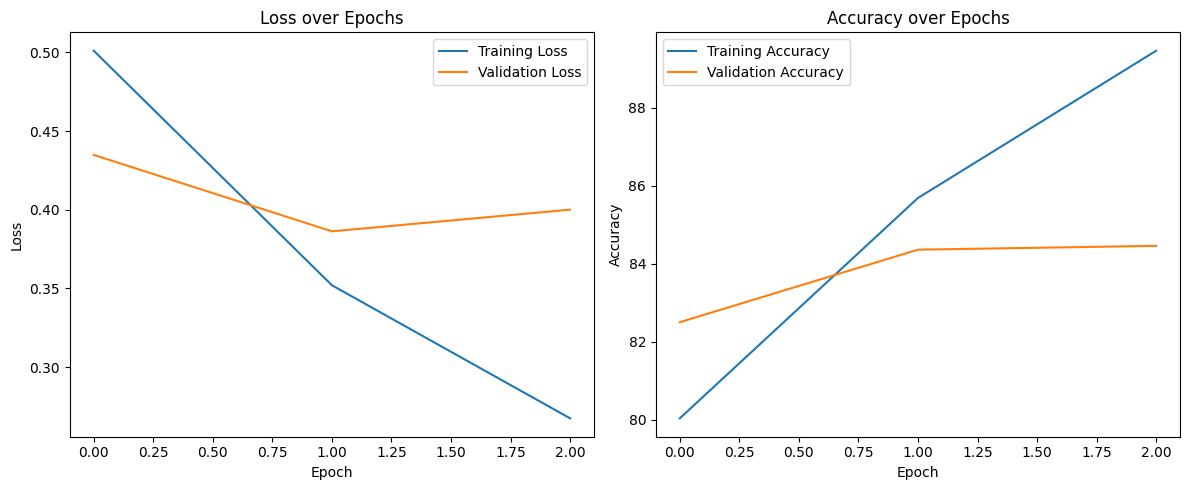

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Training Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# Performance on Unseen dataset

In [ ]:
unseen_df = pd.read_excel('/content/updated_70_samples.xlsx')     #df.sample(100)#pd.read_csv('/content/synthetic_unseen_dataset_300_balanced.csv')
unseen_df.head()

,status,original,rewritten
0,Suicidal,I am so exhausted of this. Just when I think I...,I am so worn down by all this. Right when I th...
1,Suicidal,I am 20 year old with some good friends but I ...,I am 20 years old and I have some good friends...
2,Suicidal,it is looming around the corner again. It alwa...,it is lurking around the corner again. It alwa...
3,Suicidal,there is.....foodAnd other things I will be ju...,there is.....food and other things I will get ...
4,Suicidal,I am on zoloft and focalin and it is changed m...,I am on Zoloft and Focalin and they have chang...


In [ ]:
all_probs = []

model.eval()

with torch.no_grad():
    for batch in unseen_loader:

        outputs = model(
            input_ids=batch["input_ids"].to(device),
            attention_mask=batch["attention_mask"].to(device)
        )

        probs = torch.softmax(outputs.logits, dim=1)

        all_probs.append(probs.cpu())

all_probs = torch.cat(all_probs)

print(all_probs.mean(dim=0))

tensor([0.1531, 0.0592, 0.3150, 0.1668, 0.0308, 0.1057, 0.1694])


In [ ]:
# unseen_df.drop(columns='Unnamed: 0')

In [ ]:
unseen_df["bert_text"] = unseen_df["rewritten"].apply(preprocess_text)
# Correct the specific casing issue for 'Personality Disorder'
unseen_df['true_label'] = unseen_df['status'].replace('Personality Disorder', 'Personality disorder')

# Drop rows with NaN values in 'true_label' before encoding
unseen_df.dropna(subset=['true_label'], inplace=True)

unseen_df["label"] = label_encoder.transform(unseen_df["true_label"])

unseen_encodings = tokenizer(
    unseen_df["bert_text"].tolist(),
    truncation=True,
    padding=True,
    max_length=MAX_LENGTH
)

unseen_dataset = MentalHealthDataset(
    unseen_encodings,
    unseen_df["label"]
)

unseen_loader = DataLoader(
    unseen_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [ ]:
model.eval()

unseen_predictions = []
unseen_labels = []

with torch.no_grad():
    for batch in unseen_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        predictions = torch.argmax(
            outputs.logits,
            dim=1
        )

        unseen_predictions.extend(
            predictions.cpu().numpy()
        )

        unseen_labels.extend(
            labels.cpu().numpy()
        )

In [ ]:
unseen_accuracy = accuracy_score(unseen_labels, unseen_predictions)
unseen_precision, unseen_recall, unseen_f1, _ = precision_recall_fscore_support(unseen_labels, unseen_predictions, average='macro', zero_division=0)

print(f"Unseen Accuracy   : {unseen_accuracy:.4f}")
print(f"Unseen Precision  : {unseen_precision:.4f}")
print(f"Unseen Recall     : {unseen_recall:.4f}")
print(f"Unseen F1-Score   : {unseen_f1:.4f}")

Unseen Accuracy   : 0.8143
Unseen Precision  : 0.8518
Unseen Recall     : 0.8143
Unseen F1-Score   : 0.8186


**Classification Report (Unseen Data)**

In [ ]:
print(classification_report(unseen_labels, unseen_predictions, target_names=label_encoder.classes_))

                      precision    recall  f1-score   support

             Anxiety       1.00      1.00      1.00        10
             Bipolar       1.00      0.70      0.82        10
          Depression       0.54      0.70      0.61        10
              Normal       0.91      1.00      0.95        10
Personality disorder       1.00      0.60      0.75        10
              Stress       0.90      0.90      0.90        10
            Suicidal       0.62      0.80      0.70        10

            accuracy                           0.81        70
           macro avg       0.85      0.81      0.82        70
        weighted avg       0.85      0.81      0.82        70



**Confusion Matrix (Unseen Data)**

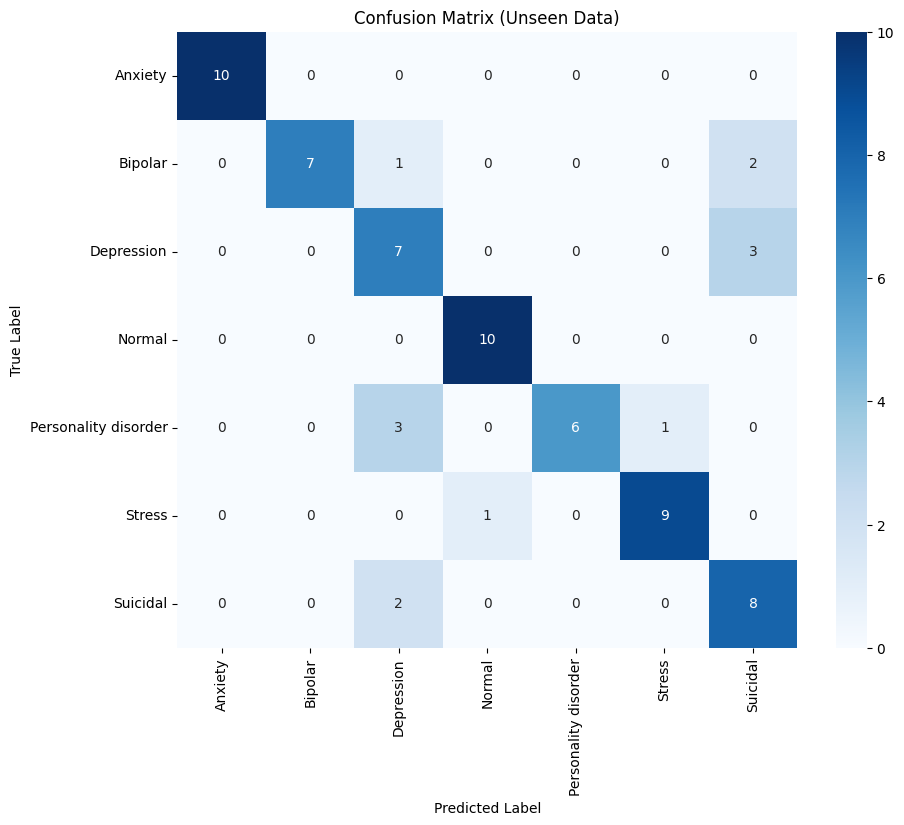

In [ ]:
cm_unseen = confusion_matrix(unseen_labels, unseen_predictions)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_unseen, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix (Unseen Data)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
errors = unseen_df.copy()

errors["true"] = unseen_labels
errors["pred"] = unseen_predictions

errors = errors[errors["true"] != errors["pred"]]

errors[["rewritten", "true_label", "pred"]].head(20)

,rewritten,true_label,pred
4,I am on Zoloft and Focalin and they have chang...,Suicidal,2
5,"I have some really bad feelings, but whenever ...",Suicidal,2
31,"I do not know how to navigate these feelings, ...",Depression,6
34,My mom made me go to a camp that she knows I g...,Depression,6
37,Since I began seeing a therapist 5 months ago ...,Depression,6
49,Next week I’ll be flying for our family vacati...,Stress,3
56,On my way into the hospital Please send good v...,Bipolar,6
57,Husband has simply about blocked me out and re...,Bipolar,2
59,"Blegh, tired of this (Rant) (triggering) I sim...",Bipolar,6
62,Anyone else have nothing in common with other ...,Personality disorder,2


In [ ]:
model.eval()
all_probs_unseen = []

with torch.no_grad():
    for batch in unseen_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        probabilities = torch.softmax(outputs.logits, dim=1)
        all_probs_unseen.extend(probabilities.cpu().numpy())

# Convert list of arrays to a single NumPy array
all_probs_unseen = np.array(all_probs_unseen)

confidences, pred_labels_tensor = torch.max(torch.tensor(all_probs_unseen), dim=1)

results = unseen_df.copy()
results["true_label_encoded"] = unseen_labels
results["predicted_label_encoded"] = pred_labels_tensor.numpy()
results["true_label"] = label_encoder.inverse_transform(unseen_labels)
results["predicted_label"] = label_encoder.inverse_transform(pred_labels_tensor.numpy())
results["confidence"] = confidences.numpy()

display(results.head())

,status,original,rewritten,bert_text,true_label,label,true_label_encoded,predicted_label_encoded,predicted_label,confidence
0,Suicidal,I am so exhausted of this. Just when I think I...,I am so worn down by all this. Right when I th...,I am so worn down by all this. Right when I th...,Suicidal,6,6,6,Suicidal,0.887158
1,Suicidal,I am 20 year old with some good friends but I ...,I am 20 years old and I have some good friends...,I am 20 years old and I have some good friends...,Suicidal,6,6,6,Suicidal,0.707550
2,Suicidal,it is looming around the corner again. It alwa...,it is lurking around the corner again. It alwa...,it is lurking around the corner again. It alwa...,Suicidal,6,6,6,Suicidal,0.874273
3,Suicidal,there is.....foodAnd other things I will be ju...,there is.....food and other things I will get ...,there is.....food and other things I will get ...,Suicidal,6,6,6,Suicidal,0.872381
4,Suicidal,I am on zoloft and focalin and it is changed m...,I am on Zoloft and Focalin and they have chang...,I am on Zoloft and Focalin and they have chang...,Suicidal,6,6,2,Depression,0.971488


# Project Summary

We successfully built and evaluated a mental health classification model using a DistilBERT architecture. First, we processed a dataset of over 53,000 text statements and their corresponding mental health statuses. This involved extensive data cleaning, including dropping unnecessary columns, handling missing values, and removing duplicate entries, resulting in a robust dataset of 51,088 samples. We also performed exploratory data analysis to understand the class distribution and textual characteristics, and applied comprehensive text preprocessing steps (e.g., Unicode normalization, URL/HTML/email/mention removal, emoji conversion) to prepare the text for the model.

The categorical mental health statuses were then encoded into numerical labels, identifying 7 distinct classes. The dataset was strategically split into training, validation, and test sets (80/10/10 ratio) to ensure balanced class representation across all splits. We used a `distilbert-base-uncased` tokenizer and determined an optimal `MAX_LENGTH` of 384 for tokenization.

For the model, we leveraged `DistilBertForSequenceClassification`, a powerful pre-trained transformer, configured for our 7 classes. The model, with approximately 67 million trainable parameters, was trained for 3 epochs on a GPU, utilizing an AdamW optimizer and a linear learning rate scheduler with warm-up. We implemented early stopping based on validation accuracy to prevent overfitting, and the best model, achieving a validation accuracy of 84.46% at epoch 3, was saved.

Upon evaluation, the model demonstrated strong performance on the held-out test set, achieving an overall accuracy of 82.81%, with macro-averaged precision, recall, and F1-scores around 80%. Notably, the macro-averaged ROC AUC was an impressive 0.9768. While performance varied slightly across individual mental health classes (e.g., 'Normal' had a very high F1-score of 0.95, while 'Personality disorder' was 0.67), the model showed good generalization.

Finally, the model's performance on a completely unseen dataset (70 samples) also yielded positive results, with an accuracy of 81.43% and macro-averaged F1-score of 81.86%. An error analysis on this unseen data revealed common misclassifications, such as 'Suicidal' statements sometimes being predicted as 'Depression', highlighting areas for potential future refinement. This comprehensive process ensures that the model is well-trained and evaluated, providing a solid foundation for mental health statement classification.